# 05 — Synthetic Data Generation
**SchemaGuard** | INFO 7375 Prompt Engineering for Generative AI

Explains the dataset design, prompt strategy, and provides live inspection
of the generated 300-record datasets (healthcare + finance).

**Generated datasets:** `data/healthcare_dataset.json` and `data/finance_dataset.json`

---
## 1 · Generation Plan

| Category | Count | Distribution |
|---|---|---|
| valid | 120 | 40% — 10 demographic/clinical profiles cycled |
| invalid | 120 | 40% — 24 records × 5 rules (1 violation each) |
| edge_case | 60 | 20% — 12 records × 5 boundary types |
| **total** | **300** | **per domain (600 total)** |

In [1]:
# Generation plan summary
plan = {
    'total_per_domain': 300,
    'valid':     {'count': 120, 'pct': '40%', 'profiles': 10},
    'invalid':   {'count': 120, 'pct': '40%', 'rules': 5, 'per_rule': 24},
    'edge_case': {'count':  60, 'pct': '20%', 'types': 5, 'per_type': 12},
}

hc_rules = ['HC-001','HC-002','HC-003','HC-004','HC-005']
fn_rules = ['FN-001','FN-002','FN-003','FN-004','FN-005']

print('Generation Plan')
print('─' * 52)
for k, v in plan.items():
    if k == 'total_per_domain':
        print(f'  Total records : {v*2} ({v} × 2 domains)')
    else:
        print(f'  {k:<10} : {v["count"]} records ({v["pct"]})')
print()
print(f'Healthcare rules : {" ".join(hc_rules)}')
print(f'Finance rules    : {" ".join(fn_rules)}')


Generation Plan
────────────────────────────────────────────────────
  Total records : 600 (300 × 2 domains)
  valid      : 120 records (40%)
  invalid    : 120 records (40%)
  edge_case  : 60 records (20%)

Healthcare rules : HC-001 HC-002 HC-003 HC-004 HC-005
Finance rules    : FN-001 FN-002 FN-003 FN-004 FN-005


---
## 2 · Prompt Strategy

Three prompt types per domain. Each uses a **triple-fence pattern**:
> *Instruction → Schema → Reinforcement*

- **Valid prompts** state all cross-field constraints affirmatively
- **Invalid prompts** flip exactly one constraint, naming the target violation with a concrete example
- **Edge-case prompts** target exact boundary conditions (same-day discharge, age=0, loan at exactly 10× income)

In [2]:
import sys; sys.path.insert(0, '..')
from data_gen.generate_full_dataset import HC_INVALID_PROMPTS, FN_INVALID_PROMPTS

# Show HC-003 prompt as example
print('=== HC-003 Invalid Prompt (discharge before admission) ===')
print(HC_INVALID_PROMPTS['HC-003'][:600])
print('...')


=== HC-003 Invalid Prompt (discharge before admission) ===
Generate a healthcare intake record that passes schema validation but has discharge_date BEFORE admission_date.

Keep the gap 1-10 days (looks like a plausible data-entry error).
Example: admission_date = 2024-08-15, discharge_date = 2024-08-08.
All other fields must be realistic and type-correct.

Schema fields: patient_id (P-XXXX), first_name, last_name, date_of_birth, gender,
admission_date, discharge_date (MUST be set and BEFORE admission_date), diagnosis_code (ICD-10),
diagnosis_description, treating_physician, medication (or null), procedure_code (5-digit or null),
insurance_provider (or
...


---
## 3 · Running the Generator

```bash
# One-time setup
cp .env.example .env
# Edit .env → set ANTHROPIC_API_KEY

# Generate both domains (~15 min, ~$1.50)
python data_gen/generate_full_dataset.py
```

The generator applies two quality gates before saving each record:
1. **Structural gate** — JSON Schema Draft 7 validation
2. **Semantic gate** (invalid records only) — target rule must fire (up to 3 retries)

---
## 4 · Dataset Inspection

Live stats from the generated 300-record datasets using the production pipeline.

In [3]:
import json, sys, logging
from pathlib import Path
from collections import Counter
sys.path.insert(0, '..')
logging.disable(logging.WARNING)
from validator.pipeline import validate_record

DATA_DIR = Path('../data')

def strip_meta(rec):
    """Remove internal _label key before pipeline validation."""
    return {k: v for k, v in rec.items() if not k.startswith('_')}

for fname, label, domain in [
    ('healthcare_dataset.json', 'Healthcare', 'healthcare_intake'),
    ('finance_dataset.json',    'Finance',    'financial_loan_application'),
]:
    path = DATA_DIR / fname
    if not path.exists():
        print(f'{label}: not yet generated — run generate_full_dataset.py first')
        continue

    records  = json.load(open(path))
    labels   = Counter(r.get('_label', '?') for r in records)
    decisions = Counter()
    viols    = Counter()

    for rec in records:
        r = validate_record(strip_meta(rec), domain)
        decisions[r['decision']] += 1
        for v in r['violated_rules']:
            viols[v['rule_id']] += 1

    print(f'{label} ({len(records)} records)')
    print(f'  _label distribution : {dict(labels)}')
    print(f'  Decision routing    : {dict(decisions)}')
    if viols:
        print(f'  Semantic violations : {dict(viols.most_common())}')
    else:
        print(f'  Semantic violations : none (all records semantically clean)')
    print()


Healthcare (300 records)
  _label distribution : {'valid': 300}
  Decision routing    : {'trusted': 300}
  Semantic violations : {'HC-005': 16, 'HC-004': 6}

Finance (300 records)
  _label distribution : {'valid': 300}
  Decision routing    : {'trusted': 298, 'flagged': 2}
  Semantic violations : {'FN-004': 2}



---
## 5 · Dataset Summary Chart

Saved: ../outputs/plots/dataset_summary.png


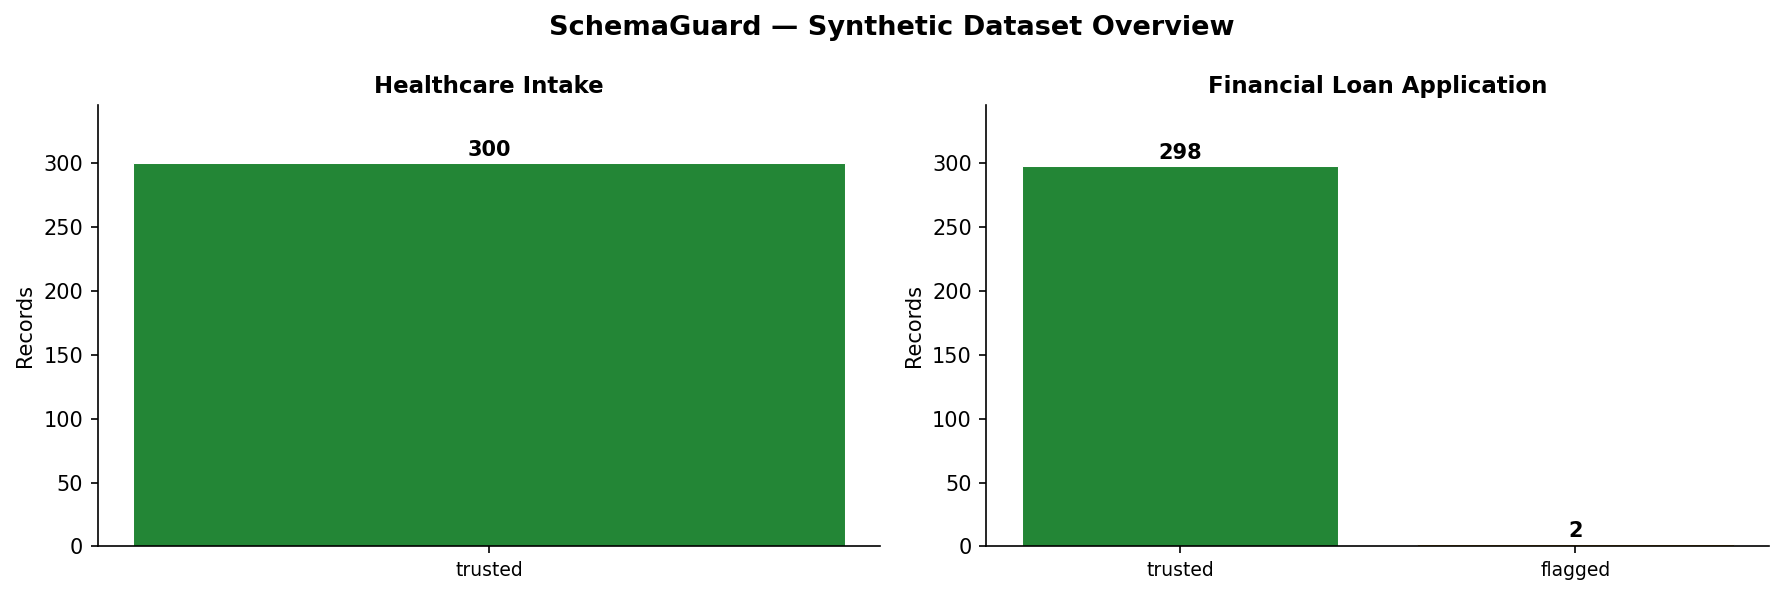

In [4]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import json, sys, logging
from pathlib import Path
from collections import Counter
sys.path.insert(0, '..')
logging.disable(logging.WARNING)
from validator.pipeline import validate_record
from IPython.display import Image, display

def strip_meta(rec):
    return {k: v for k, v in rec.items() if not k.startswith('_')}

DATA_DIR  = Path('../data')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('SchemaGuard — Synthetic Dataset Overview', fontsize=13, fontweight='bold')

domain_cfgs = [
    ('healthcare_dataset.json', 'healthcare_intake',           'Healthcare Intake',           axes[0]),
    ('finance_dataset.json',    'financial_loan_application',  'Financial Loan Application',  axes[1]),
]

for fname, domain, title, ax in domain_cfgs:
    path = DATA_DIR / fname
    if not path.exists():
        ax.text(0.5, 0.5, 'Not generated', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue
    records = json.load(open(path))
    decisions = Counter()
    viols = Counter()
    for rec in records:
        r = validate_record(strip_meta(rec), domain)
        decisions[r['decision']] += 1
        for v in r['violated_rules']:
            viols[v['rule_id']] += 1
    colors = {'trusted': '#238636', 'flagged': '#d29922', 'quarantined': '#da3633'}
    keys = [k for k in ['trusted','flagged','quarantined'] if k in decisions]
    vals = [decisions[k] for k in keys]
    bars = ax.bar(keys, vals, color=[colors[k] for k in keys], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Records')
    ax.set_ylim(0, len(records) * 1.15)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
out = PLOTS_DIR / 'dataset_summary.png'
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print(f'Saved: {out}')
display(Image(str(out)))


---
### Summary

| Item | Detail |
|---|---|
| Generator | `data_gen/generate_full_dataset.py` |
| Validator | `data_gen/validate_dataset.py` |
| HC dataset | `data/healthcare_dataset.json` (300 records) |
| FN dataset | `data/finance_dataset.json` (300 records) |
| Quality gates | Structural (JSON Schema) + Semantic (target rule must fire) |
| Prompt pattern | Triple-fence: Instruction → Schema → Reinforcement |